## Quantization
Basically, Neural networks are trained with floating point format.

Floating point format allows for high precision of computation and wide range of represented values.

It's very convenient, especially for training, where gradient may takes values from the very large to very small.

A model trained with floating point format should be also inferred in this format.
However, floating point operations are highly computationally complex
and need much higher computing power for multiply and accumulate operations than integer operations.

Because of that, many quantization techniques were introduced to greatly reduce computational complexity and memory footprints of neural networks during inference.

Let $r$ be a floating point network parameter (weight) or an input (activation) to a layer. It can be represented by an integer value $Q$ in a process called **Quantization**.

Visualization of a uniform (left) and non-uniform quantization (right):

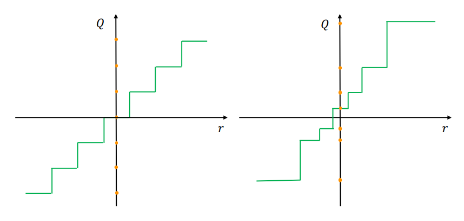

A visualization of quantizing a $[\alpha, \beta]$ range of real numbers into 8-bit integer representation in symmetrical case ($\alpha = -\beta$):

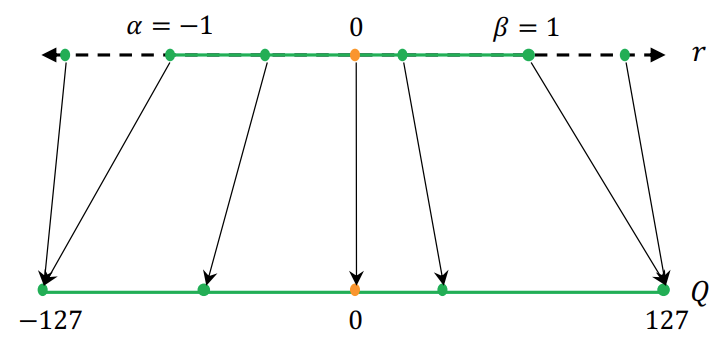

Let us introduce a $quantize(r)$ function that maps a real value $r$ into quantized integer value $Q$:

\begin{equation}
Q = quantize(r) = \lfloor \frac{r}{S} \rfloor \tag{1}
\end{equation}

Where

\begin{equation}
S = \frac{\beta - \alpha}{n}
\end{equation}

is called quantization scale, $n$ is the number of quantization steps and $\lfloor x \rfloor$ is the floor operation (keep only the integer part of a number). Typically $n = 2^N - 1$, where $N$ is the number of bits for integer representation.

Similarly, an inverse $dequantize(Q)$ transformation is defined as:

\begin{equation}
r = dequantize(Q) = SQ \tag{2}
\end{equation}

However, there is one problem with this approach when we wish to quantize  asymmetrical range of real numbers:

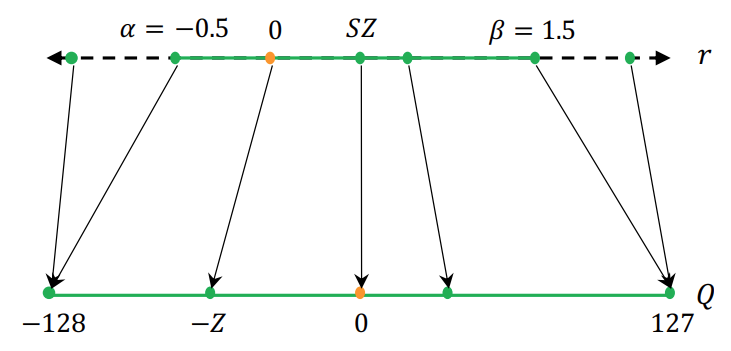

In this case, applying equation $(1)$ for $\alpha = -0.5$ and $\beta = 1.5$ gives us:

$quantize(\alpha) = \lfloor \frac{n}{\beta - \alpha} \alpha \rfloor = \lfloor \frac{255}{2} (-0.5) \rfloor$ = -64

$quantize(\beta) = 191$

But this is outside INT8 datatype range of [-128, 127]!

To fix this, a so-called zero-point parameter $Z$ is introduced into quantization functions $(1)$ and $(2)$:

\begin{equation}
quantize(r) = \lfloor \frac{r}{S} \rfloor + Z \tag{3}
\end{equation}

\begin{equation}
dequantize(Q) = S(Q - Z) \tag{4}
\end{equation}

Notice that $dequantize()$ function is lossless (every quantized value has its real-valued representation), but the $quantize()$ function loses some information due to the floor operation (not every real-valued number can be represented).

During training of quantized models (so-called **Quantization-Aware Training (QAT)**), the weights $w$ are stored as real-valued numbers, but during forward pass, $\hat{w}$ weights are used:

\begin{equation}
w' = dequantize(quantize(w)) \tag{5}
\end{equation}

So $w'$ is real-valued but with values restricted to only those that can be exactly represented by integer values.
Because of that, $w'$ is sometimes called a **scaled integer** and $dequantize(quantize(x))$ operation is typically known as **fake quantization**.

The learning step is applied to the original weights $w$. This way we keep floating-point resolution for backpropagation and restrict the model to only use quantized values during inference.


For quantization-aware training, we will use the [`Brevitas`](https://github.com/Xilinx/brevitas) library is used with [`PyTorch`](https://pytorch.org/) framework.

To go through the tutorial you only need to run the next cells with the code.

Some of them needs to be filled with proper python code  :)

Creating a directory for dataset and installing necessary libraries:

In [1]:
!mkdir data
# !pip install torch==2.0.0 torchvision==0.15.1 torchaudio==2.0.1 torchtext==0.15.1
# !pip install torch==2.0.0 torchvision==0.15.1 torchaudio==2.0.1 torchtext==0.15.1 --index-url https://download.pytorch.org/whl/cu118
# !pip install brevitas==0.9.0
!pip install numpy
!pip install torch torchvision
!pip install matplotlib
!pip install tqdm
!pip install brevitas
!pip install onnx onnxoptimizer


mkdir: cannot create directory ‘data’: File exists
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [2]:
!pip install --upgrade pip
!pip install brevitas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.6 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Attempting uninstall: pip
    Found existing installation: pip 22.0.2
    Uninstalling pip-22.0.2:
      Successfully uninstalled pip-22.0.2


In [3]:
!pip install pytorch_lightning
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 11.4 MB/s  0:00:011.6 MB/s eta 0:00:01:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
brevitas 0.12.1 requires numpy<=1.26.4, but you have numpy 2.2.6 which is incompatible.


In [1]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torch import nn
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import List, Tuple, Dict
from copy import deepcopy
from abc import ABC, abstractmethod
from typing import Any, Callable, Tuple
import tqdm.auto as tqdm


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Using", device, "device.")

def set_random_seed(seed:int = 0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


Using cuda device.


/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


### Datasets and dataloaders

Instantiation of MNIST dataloaders for training and validation.

Additionally, few elements of train set are displayed.

In [2]:
# from torchvision.transforms import ToTensor

# BATCH_SIZE = 64
# set_random_seed(0)

# train_dataset = datasets.MNIST('data',
#                               train=True,
#                               download=True,
#                               transform=ToTensor())
# test_dataset = datasets.MNIST('data',
#                               train=False,
#                               download=True,
#                               transform=ToTensor())

# train_loader = DataLoader(train_dataset,
#                           batch_size=BATCH_SIZE,
#                           shuffle=False)
# test_loader = DataLoader(test_dataset,
#                           batch_size=BATCH_SIZE,
#                           shuffle=False)

# print("len(train_loader) =", len(train_loader))
# print("len(test_loader) =", len(test_loader))

# plt.gray()
# loader = train_loader
# for X, y in loader:
#     print("Input data shape:", X.shape)
#     print("Reference data shape:", y.shape)

#     ROWS, COLS = 4, 6
#     fig, axs = plt.subplots(ROWS, COLS)
#     fig.set_size_inches(COLS*2,ROWS*2)
#     axs = np.array(axs).flatten().tolist()

#     for i, ax in enumerate(axs):
#         img = X[i,...]
#         class_label = loader.dataset.classes[y[i]]
#         img = img.permute(1,2,0)[:, :, 0]
#         ax.imshow(img)
#     plt.show()
#     break

import importlib.util
import sys


BATCH_SIZE = 64
set_random_seed(0)

def load_module(module_name, path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

custom_transform = load_module(
    "custom_transform",
    "/home/patryk/Desktop/MASTER_THIESIS/net_implementation/src/custom_transform.py"
)

spectrogram_datamodule = load_module(
    "spectrogram_datamodule",
    "/home/patryk/Desktop/MASTER_THIESIS/net_implementation/src/spectogram_datamodule.py"
)

ct = custom_transform.ShuffleChannels()

SpektogramDatasetTrain = spectrogram_datamodule.SpektogramDataset("/home/patryk/Desktop/MASTER_THIESIS/net_implementation/spectogram_wieliczka", ct)
SpektogramDatasetTest = spectrogram_datamodule.SpektogramDataset("/home/patryk/Desktop/MASTER_THIESIS/net_implementation/spectogram_ziemowit")

train_loader = DataLoader(SpektogramDatasetTrain,
                          batch_size=BATCH_SIZE,
                          shuffle=False)
test_loader = DataLoader(SpektogramDatasetTest,
                          batch_size=BATCH_SIZE,
                          shuffle=False)

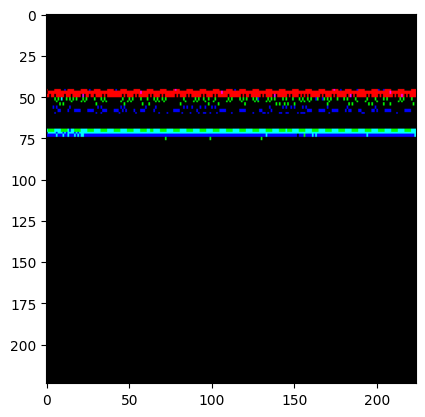

In [3]:
plt.imshow(next(iter(train_loader))[0][0].numpy().transpose(1, 2, 0))

In [6]:
print(torch.version.cuda)

12.1


### Network definition

Defining a network architecture - it is rather simple, but it's enough for the task.

🔔 **TODO (1)** Because the input size of the last fully-connected layer depends on the input shape and previous convolutional layers, we need to compute intermediate map shapes with every convolutional layer added (what is the shape of the output of a convolutional layer with given input shape, kernel size, padding and stride?). Compute `map_shape` after convolutional and maxpooling layers in `TODO` sections below:

**Hint 1:** You can read about convolutional layers [in this chapter](https://d2l.ai/chapter_convolutional-neural-networks/padding-and-strides.html).

**Hint 2:** you can verify intermediate map shapes by printing the shape of a `x` variable in `forward()` method.

In [ ]:
import torch
import torch.nn as nn
import brevitas.nn as qnn
from brevitas.core.quant import QuantType
from brevitas.core.scaling import ScalingImplType

from brevitas_examples.imagenet_classification.models.common import CommonIntActQuant, CommonUintActQuant
from brevitas_examples.imagenet_classification.models.common import CommonIntWeightPerChannelQuant, CommonIntWeightPerTensorQuant

class QAlexNetV5(nn.Module): # Uproszczone dziedziczenie
    def __init__(self,
                 input_shape=(3, 224, 224),
                 num_classes=2,
                 channels=[32, 64, 128, 256],
                 ksize=[3, 3, 3, 3],
                 padding=[1, 1, 1, 1],
                 max_pool=[1, 1, 0, 0],
                 weights_bitwidth=2,
                 activations_bitwidth=2):

        super(QAlexNetV5, self).__init__()
        
        all_channels = [input_shape[0]] + channels
        layers_list = []
        
        # Obliczenia map_shape robimy na czystym Pythonie (int)
        h, w = input_shape[1], input_shape[2]
        current_ch = input_shape[0]

        for i, (ch_in, ch_out, ks, p, mp) in enumerate(zip(all_channels[:-1],
                                                        all_channels[1:],
                                                        ksize,
                                                        padding,
                                                        max_pool)):
            # Conv
            layers_list.append(qnn.QuantConv2d(
                ch_in, ch_out, ks,
                weight_bit_width=weights_bitwidth,
                padding=p,
                weight_quant=CommonIntWeightPerChannelQuant
            ))
            
            # Aktualizacja wymiarów (czysty Python)
            h = (h + 2 * p - ks) + 1
            w = (w + 2 * p - ks) + 1
            
            # ReLU
            layers_list.append(qnn.QuantReLU(
                bit_width=activations_bitwidth,
                return_quant_tensor=True,
                act_quant=CommonUintActQuant
            ))
            
            # MaxPool
            if mp:
                layers_list.append(nn.MaxPool2d(2, 2))
                h //= 2
                w //= 2

        self.layers = nn.Sequential(*layers_list)
        
        # Obliczamy końcowy rozmiar jako int
        conv_features_length = int(ch_out * h * w)
        
        self.fc = qnn.QuantLinear(
            in_features=conv_features_length,
            out_features=num_classes,
            bias=False,
            weight_bit_width=weights_bitwidth
        )

    def forward(self, x):
        x = self.layers(x)
        # Używamy flatten(1), co jest bezpieczniejsze dla eksportu ONNX
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    

net = QAlexNetV5()
net.eval()

import torch

# Wyłączamy sprawdzanie 'strażników' danych
torch._dynamo.config.suppress_errors = True
from brevitas.export import export_qonnx

# 1. Upewnij się, że model jest w trybie eval
net.eval()

# 2. Dummy input
dummy_input = torch.randn(1, 3, 224, 224)

# 3. WYMUSZENIE WYŁĄCZENIA TORCH.EXPORT
# W wielu wersjach Brevitasa można to zrobić przekazując odpowiedni parametr 
# lub używając managera kontekstu, ale najskuteczniejszą metodą "brute-force" 
# dla FINN jest użycie starego managera eksportu:

from brevitas.export.onnx.qonnx.manager import QONNXManager

QONNXManager.export(net, dummy_input, "qalexnet_exported.onnx")
# class _AlexNet(nn.Module):

#     def forward(self, x):

#         for layer in self.layers:
#             x = layer(x)

#         x = x.view(x.shape[0], -1)
#         x = self.fc(x)
#         return x


# class QAlexNetV5(_AlexNet):

# 	def __init__(self,
# 					input_shape = (3, 224, 224),
# 					num_classes = 2,
# 					channels = [32, 64, 128, 256], # number of conv filters
# 					ksize = [3, 3, 3, 3], # kernels sizes
# 					padding = [1, 1, 1, 1], # padding sizes
# 					max_pool = [1, 1, 0, 0], # use maxpool after conv or not
# 					weights_bitwidth = 2,
# 					activations_bitwidth = 2,
# 					device = 'cpu'
# 					):

# 		super(QAlexNetV5, self).__init__()
# 		channels = [input_shape[0]] + channels
# 		self.layers = nn.ModuleList()

# 		# initialize map shape with input shape
# 		map_shape = [input_shape[0], input_shape[1], input_shape[2]]

# 		for i, (ch_in, ch_out, ks, p, mp) in enumerate(zip(channels[:-1],
# 														channels[1:],
# 														ksize,
# 														padding,
# 														max_pool)):

# 			self.layers.append(qnn.QuantConv2d(ch_in,
# 												ch_out,
# 												ks,
# 												weight_bit_width = weights_bitwidth,
# 												padding = p,
# 												weight_quant = CommonIntWeightPerChannelQuant
# 												))

# 			#TODO 1 predict the map shape so it is the same as convolution output
# 			map_shape[0] = ch_out
# 			map_shape[1] = (map_shape[1] + 2 * p - ks) + 1
# 			map_shape[2] = (map_shape[2] + 2 * p - ks) + 1
# 			#TODO 1

# 			self.layers.append(qnn.QuantReLU(bit_width = activations_bitwidth,
# 												return_quant_tensor = True,
# 												act_quant = CommonUintActQuant
# 												))
# 			if(mp):
# 				self.layers.append(nn.MaxPool2d(2, 2))
# 				#TODO 1 modify the map shape accordingly when using maxpooling
# 				map_shape[1] = map_shape[1] // 2
# 				map_shape[2] = map_shape[2] // 2
# 				#TODO 1

# 		# finally we can compute the input size of the fully-connected classifier
# 		conv_features_length = torch.prod(torch.tensor(map_shape))
# 		self.fc = qnn.QuantLinear(in_features = conv_features_length,
# 							out_features = num_classes,
# 							bias = False,
# 							weight_bit_width = weights_bitwidth)

In [9]:
!pip install setuptools

### Defining an accuracy metric
for network scoring purpose.

In [10]:
class BaseMetric(ABC):
    @abstractmethod
    def __call__(self, y_pred, y_ref) -> Any:
        raise NotImplementedError()


class AccuracyMetric(BaseMetric):
    @torch.no_grad()
    def __call__(self, y_pred: torch.Tensor, y_ref: torch.Tensor) -> torch.Tensor:
        """
        :param y_pred: tensor of shape (batch_size, num_of_classes) type float
        :param y_ref: tensor with shape (batch_size,) and type Long
        :return: scalar tensor with accuracy metric for batch
        """
        y_pred = y_pred.argmax(1)
        cmp = y_pred == y_ref
        # scalar value
        score: torch.Tensor = cmp.sum() / cmp.shape[0]
        return score

### Defining main training functions
and util function for history printing

In [11]:
def train_test_pass(model: torch.nn.Module,
                    data_generator: Callable,
                    criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
                    metric: BaseMetric,
                    optimizer: torch.optim.Optimizer = None,
                    mode: str = 'test',
                    device = torch.device('cpu')) -> Tuple[torch.nn.Module, float, float]:
    """
    Function calculates mean loss and metric values for dataset from data_generator.
    If mode == 'train': backward propagation and optimizer step is done.
    else: not.

    :param model: model to evaluate / train
    :param data_generator: data generator / loader, returns data of dataset in format (input_data, labels)
    :param criterion: criterion function to calculate mean loss for a batch
    :param metric: object to calculate mean metric value for a batch
    :param optimizer: Optimizer object to update parameters of model, used only in 'train' mode
    :param update_period: number of batches to update parameters
    :param mode: function mode: 'train' or 'test'
    :param device: torch device to execute on all operations
    :return: trained_model, mean_loss, mean_metric
    """
    # change model mode to train or test
    if mode == 'train':
        model.train(True)
    elif mode == 'test':
        model.eval()
    else:
        raise RuntimeError("Unsupported mode.")

    # move model to device
    model = model.to(device)

    # reset model parameters' gradients with optimizer
    if mode == 'train':
        optimizer.zero_grad()

    total_loss: float = 0.0
    total_accuracy: float = 0.0
    samples_num: int = 0

    pbar = tqdm.tqdm(enumerate(data_generator), total=len(data_generator))
    for i, (X, y_ref) in pbar:
        # convert tensors to device
        X = X.to(device)
        y_ref = y_ref.to(device)

        # process by network
        if mode == 'train':
            y_pred = model(X)
        else:
            with torch.no_grad():
                y_pred = model(X)
        # calculate loss and metric
        loss: torch.Tensor = criterion(y_pred, y_ref)
        accuracy = metric(y_pred, y_ref)

        if mode == 'train':
            # designate gradient based on loss
            loss.backward()
            # update parameters with optimizer
            optimizer.step()
            # gradient designation sums it's values from previous passes
            # there is needed zeroing stored values of gradient
            optimizer.zero_grad()
        # sum state with previous iterations
        total_loss += loss.item() * y_pred.shape[0]
        total_accuracy += accuracy.item() * y_pred.shape[0]
        samples_num += y_pred.shape[0]
        pbar.set_description(f'Loss:{total_loss / samples_num:0>8.5f}'
                             f'| {metric.__class__.__name__}:{total_accuracy / samples_num:0>8.5f}')

    if samples_num == 0:
        return model, 0.0, 0.0

    return model, total_loss / samples_num, total_accuracy / samples_num


def training(model,
             train_loader,
             test_loader,
             loss_fcn,
             metric,
             optimizer,
             epoch_max,
             device):
    """
    Function trains model for given train dataset, criterion and hyper-parameters with given optimizer.

    :param model: model for training
    :param train_loader: data loader, returns data of training dataset in format (input_data, labels)
    :param test_loader: data loader, returns data of test / validation dataset in format (input_data, labels)
    :param criterion: criterion function to calculate mean loss for a batch
    :param metric: object to calculate mean metric value for a batch
    :param optimizer: Optimizer object to update parameters of model, used only in 'train' mode
    :param update_period: number of batches to update parameters
    :param epoch_max: number of epochs to train model
    :param device: torch device to execute on all operations
    :return: trained_model, history of training as dictionary
    """

    loss_train = []
    loss_test = []
    acc_train = []
    acc_test = []

    for e in range(epoch_max):
        epoch = e+1
        print(f'Epoch {epoch} / {epoch_max}: STARTED')
        print('TRAINING', end='')
        net, loss, acc = train_test_pass(model,
                                         train_loader,
                                         loss_fcn,
                                         metric,
                                         optimizer,
                                         mode='train',
                                         device=device)
        loss_train.append(loss)
        acc_train.append(acc)

        print('\rVALIDATION', end='')
        net, loss, acc = train_test_pass(model,
                                         test_loader,
                                         loss_fcn,
                                         metric,
                                         optimizer,
                                         mode='test',
                                         device=device)
        loss_test.append(loss)
        acc_test.append(acc)

        print(f'\rAfter epoch {epoch}: loss={loss_train[-1]:.4f} '
              f'acc={acc_train[-1]:.4f} val_loss={loss_test[-1]:.4f} val_acc={acc_test[-1]:.4f}')
        print(f'Epoch {epoch} / {epoch_max}: FINISHED\n')

    return model, {'loss_train': loss_train,
                   'acc_train': acc_train,
                   'loss_test': loss_test,
                   'acc_test': acc_test}


def plot_history(history):
    plt.plot(history['loss_train'], label='train')
    plt.plot(history['loss_test'], label='test')
    plt.legend()
    plt.title("History of loss")
    plt.show()

    plt.plot(history['acc_train'], label='train')
    plt.plot(history['acc_test'], label='test')
    plt.legend()
    plt.title("History of accuracy")
    plt.show()

### Network instantiation and training

Instantiation of a network with 4-bit quantization of feature maps and weights.
We also create a random input to check if there are no errors in the architecture.

Then we initialize accuracy metric, training criterion and the optimization algorithm

Finally, we train the network for 5 epochs - should be enough for a small model like ours.

In [31]:
net = QAlexNetV5(weights_bitwidth = 8,
                 activations_bitwidth = 8).to('cpu')

In [ ]:
set_random_seed(0)
net = QAlexNetV5(weights_bitwidth = 8,
                 activations_bitwidth = 8).to('cpu')
# test on a random input
test_input = torch.rand(1, 3, 224, 224).to('cpu')
testout = net(test_input)
print(testout.shape)

# initialize an accuracy metric, a training criterion (cross entropy loss) and the optimization algorithm (Stochastic Gradient Descent):
metric = AccuracyMetric()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01, momentum=0.8, weight_decay=0.001)

# start training
net, history = training(net, train_loader, test_loader, criterion, metric, optimizer, epoch_max=50, device='cpu')
plot_history(history)
# torch.save(net.state_dict(), "qalexnet_weights.pt")

In [13]:
!pip show torch

Name: torch
Version: 2.11.0+cu126
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /home/patryk/Desktop/venv/FINN_venv/lib/python3.10/site-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: brevitas, pytorch-lightning, torchmetrics, torchvision, unfoldNd


In [14]:
torch.cuda.is_available()

True

## Network export to the onnx format


In [ ]:
from brevitas.export import export_qonnx

net.train(False)
export_qonnx(net, torch.rand(1, 3, 224, 224).to('cpu'), "qalexnet_exported.onnx")

In [ ]:
import torch
from brevitas.export import export_qonnx

# przygotowanie modelu
net.eval()
dummy_input = torch.rand(1, 3, 224, 224, dtype=torch.float32)

# eksport do ONNX
export_qonnx(
    net,
    dummy_input,
    "qalexnet_exported.onnx"
)

print("Model wyeksportowany do ONNX.")

It is also convenient to save an example input for later hardware tests (in a `[BATCH, H, W, CHANNELS]` format and with 8-bit range).

torch.Size([1, 1, 28, 28])
tensor([[-1.2534, -2.1324,  2.4690,  0.2988, -3.1450, -5.1817, -9.4262, 16.2791,
         -2.0425,  3.4815]], device='cuda:0', grad_fn=<MmBackward0>)


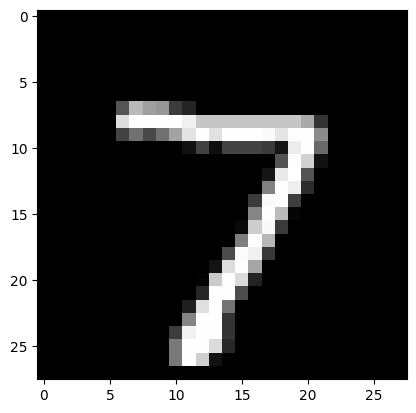

In [ ]:
for X, y in test_loader:
    print(X[:1].shape)
    out = net(X[:1].to(device))
    print(out)

    #visualize
    x = X[0].permute(1, 2, 0)
    plt.imshow(x)

    #save for hardware tests
    x = x.unsqueeze(0) * 255
    np.save('test_mnist.npy', x)
    break